In [1]:
#Imports
import pandas as pd
import requests
import matplotlib.pyplot as plt
import openmeteo_requests
from openmeteo_requests.Client import OpenMeteoRequestsError
from retry_requests import retry 
import requests_cache
import numpy as np
import os
import time
from datetime import datetime
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import xgboost #dont need anymore
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as lm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

Data Sources:
Electricity (Mwh): https://www.eia.gov/opendata/browser/electricity/retail-sales?frequency=monthly&data=customers;price;sales;&sortColumn=period;&sortDirection=desc

Gas (MMCF): # https://www.eia.gov/opendata/browser/natural-gas/cons/sum?frequency=monthly&data=value;&sortColumn=period;&sortDirection=desc

Weather: https://open-meteo.com/en/docs/historical-weather-api

#### Dictionaries

In [2]:
#Dictionaries for canonicalization of state names
state_dict_gas = {"USA-AR":"ARKANSAS", "USA-WV":"WESTVIRGINIA", "USA-OR":"OREGON", 
	"USA-HI":"HAWAII", "USA-MD":"MARYLAND", "CALIFORNIA":"CALIFORNIA", 
	"USA-VA":"VIRGINIA", "USA-PA":"PENNSYLVANIA", "USA-IN":"INDIANA", 
	"WASHINGTON":"WASHINGTON", "USA-MI":"MICHIGAN", "USA-AK":"ALASKA", 
	"COLORADO":"COLORADO", "USA-SD":"SOUTHDAKOTA", "USA-ME":"MAINE", 
	"TEXAS":"TEXAS", "USA-NE":"NEBRASKA", "MINNESOTA":"MINNESOTA", 
	"USA-UT":"UTAH", "MASSACHUSETTS":"MASSACHUSETTS", "USA-MS":"MISSISSIPPI", 
	"USA-KS":"KANSAS", "OHIO":"OHIO", "USA-IL":"ILLINOIS", 
	"USA-ND":"NORTHDAKOTA", "USA-OK":"OKLAHOMA", "USA-NJ":"NEWJERSEY", 
	"USA-CT":"CONNECTICUT", "USA-WI":"WISCONSIN", "NEWYORK":"NEWYORK", "NEW YORK":"NEWYORK", 
	"USA-WY":"WYOMING", "USA-SC":"SOUTHCAROLINA", "USA-GA":"GEORGIA", 
	"USA-TN":"TENNESSEE", "USA-ID":"IDAHO", "USA-IA":"IOWA", "USA-AZ":"ARIZONA", 
	"USA-RI":"RHODEISLAND", "USA-VT":"VERMONT", "USA-LA":"LOUISIANA", "USA-MT":"MONTANA", 
	"USA-KY":"KENTUCKY", "FLORIDA":"FLORIDA", "USA-NV":"NEVADA", "USA-NM":"NEWMEXICO", 
	"USA-NH":"NEWHAMPSHIRE", "USA-DE":"DELAWARE", 
	"USA-AL":"ALABAMA", "USA-NC":"NORTHCAROLINA", "USA-MO":"MISSOURI"
	}
state_dict_electricity = {
    "Alaska": "ALASKA", "Alabama": "ALABAMA", "Arkansas": "ARKANSAS", 
    "Arizona": "ARIZONA", "California": "CALIFORNIA", "Colorado": "COLORADO", 
    "Connecticut": "CONNECTICUT", 
    "Delaware": "DELAWARE", "Florida": "FLORIDA", "Georgia": "GEORGIA", "Hawaii": "HAWAII", "Iowa": "IOWA", 
    "Idaho": "IDAHO", "Illinois": "ILLINOIS", "Indiana": "INDIANA", "Kansas": "KANSAS", 
    "Kentucky": "KENTUCKY", "Louisiana": "LOUISIANA", "Massachusetts": "MASSACHUSETTS", "Maryland": "MARYLAND", 
    "Maine": "MAINE", "Michigan": "MICHIGAN", "Minnesota": "MINNESOTA", "Missouri": "MISSOURI", 
    "Mississippi": "MISSISSIPPI", "Montana": "MONTANA", "North Carolina": "NORTHCAROLINA", "North Dakota": "NORTHDAKOTA", 
    "Nebraska": "NEBRASKA", "New Hampshire": "NEWHAMPSHIRE", 
    "New Jersey": "NEWJERSEY", "New Mexico": "NEWMEXICO", "Nevada": "NEVADA", "New York": "NEWYORK", 
    "Ohio": "OHIO", "Oklahoma": "OKLAHOMA", "Oregon": "OREGON", "Pennsylvania": "PENNSYLVANIA", 
    "Rhode Island": "RHODEISLAND", "South Carolina": "SOUTHCAROLINA", 
    "South Dakota": "SOUTHDAKOTA", "Tennessee": "TENNESSEE", "Texas": "TEXAS", 
    "Utah": "UTAH", "Virginia": "VIRGINIA", "Vermont": "VERMONT", "Washington": "WASHINGTON", 
    "Wisconsin": "WISCONSIN", "West Virginia": "WESTVIRGINIA", "Wyoming": "WYOMING"
} 

## Dictionary for lat/long coordinates of each state:
state_coords = {
    "ALABAMA": (32.806671, -86.791130),
    "ALASKA": (61.370716, -152.404419),
    "ARIZONA": (33.729759, -111.431221),
    "ARKANSAS": (34.969704, -92.373123),
    "CALIFORNIA": (36.116203, -119.681564),
    "COLORADO": (39.059811, -105.311104),
    "CONNECTICUT": (41.597782, -72.755371),
    "DELAWARE": (39.318523, -75.507141),
    "FLORIDA": (27.766279, -81.686783),
    "GEORGIA": (33.040619, -83.643074),
    "HAWAII": (21.094318, -157.498337),
    "IDAHO": (44.240459, -114.478828),
    "ILLINOIS": (40.349457, -88.986137),
    "INDIANA": (39.849426, -86.258278),
    "IOWA": (42.011539, -93.210526),
    "KANSAS": (38.526600, -96.726486),
    "KENTUCKY": (37.668140, -84.670067),
    "LOUISIANA": (31.169546, -91.867805),
    "MAINE": (44.693947, -69.381927),
    "MARYLAND": (39.063946, -76.802101),
    "MASSACHUSETTS": (42.230171, -71.530106),
    "MICHIGAN": (43.326618, -84.536095),
    "MINNESOTA": (45.694454, -93.900192),
    "MISSISSIPPI": (32.741646, -89.678696),
    "MISSOURI": (38.456085, -92.288368),
    "MONTANA": (46.921925, -110.454353),
    "NEBRASKA": (41.125370, -98.268082),
    "NEVADA": (38.313515, -117.055374),
    "NEWHAMPSHIRE": (43.452492, -71.563896),
    "NEWJERSEY": (40.298904, -74.521011),
    "NEWMEXICO": (34.840515, -106.248482),
    "NEWYORK": (42.165726, -74.948051),
    "NORTHCAROLINA": (35.630066, -79.806419),
    "NORTHDAKOTA": (47.528912, -99.784012),
    "OHIO": (40.388783, -82.764915),
    "OKLAHOMA": (35.565342, -96.928917),
    "OREGON": (44.572021, -122.070938),
    "PENNSYLVANIA": (40.590752, -77.209755),
    "RHODEISLAND": (41.680893, -71.511780),
    "SOUTHCAROLINA": (33.856892, -80.945007),
    "SOUTHDAKOTA": (44.299782, -99.438828),
    "TENNESSEE": (35.747845, -86.692345),
    "TEXAS": (31.054487, -97.563461),
    "UTAH": (40.150032, -111.862434),
    "VERMONT": (44.045876, -72.710686),
    "VIRGINIA": (37.769337, -78.169968),
    "WASHINGTON": (47.400902, -121.490494),
    "WESTVIRGINIA": (38.491226, -80.954453),
    "WISCONSIN": (44.268543, -89.616508),
    "WYOMING": (42.755966, -107.302490)
}
state_abbrev = {
    "ALABAMA": "AL", "ALASKA": "AK", "ARIZONA": "AZ", "ARKANSAS": "AR",
    "CALIFORNIA": "CA", "COLORADO": "CO", "CONNECTICUT": "CT", "DELAWARE": "DE",
     "FLORIDA": "FL", "GEORGIA": "GA", "HAWAII": "HI",
    "IDAHO": "ID", "ILLINOIS": "IL", "INDIANA": "IN", "IOWA": "IA", "KANSAS": "KS",
    "KENTUCKY": "KY", "LOUISIANA": "LA", "MAINE": "ME", "MARYLAND": "MD",
    "MASSACHUSETTS": "MA", "MICHIGAN": "MI", "MINNESOTA": "MN", "MISSISSIPPI": "MS",
    "MISSOURI": "MO", "MONTANA": "MT", "NEBRASKA": "NE", "NEVADA": "NV",
    "NEWHAMPSHIRE": "NH", "NEWJERSEY": "NJ", "NEWMEXICO": "NM", "NEWYORK": "NY",
    "NORTHCAROLINA": "NC", "NORTHDAKOTA": "ND", "OHIO": "OH", "OKLAHOMA": "OK",
    "OREGON": "OR", "PENNSYLVANIA": "PA", "RHODEISLAND": "RI", "SOUTHCAROLINA": "SC",
    "SOUTHDAKOTA": "SD", "TENNESSEE": "TN", "TEXAS": "TX", "UTAH": "UT",
    "VERMONT": "VT", "VIRGINIA": "VA", "WASHINGTON": "WA", "WESTVIRGINIA": "WV",
    "WISCONSIN": "WI", "WYOMING": "WY"
}

## Energy Data

#### API call:

In [3]:
# Interacts with the EIA (Energy Information Administration - USA) to fetch electricity and natural gas consumer values per state.
# Saves data into CSV for later use to circumvent multitude of API calls.       (longer-term maintenance may be required for API interface)

# Helper function to fetch and flatten EIA API data
def fetch_eia_data(url, api_key, params, chunk_size=5000):
    all_data = []
    offset = 0

    # Can I do this? Does the API break the loop?
    while True:
        # Update offset and api_key
        params.update({
            "api_key": api_key,
            "offset": offset,
            "length": chunk_size
        })
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        # Extract rows
        rows = data.get("response", {}).get("data", [])
        if not rows:
            break

        all_data.extend(rows)

        # Check if we reached the end
        total_count = data.get("response", {}).get("total", 0)
        total_count = int(total_count)
        offset += len(rows)
        if offset >= total_count:
            break

    # Convert to DataFrame
    df = pd.json_normalize(all_data)
    return df

params_gas = {
    "frequency": "monthly",
    "data[0]": "value",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}

params_electric = {
    "frequency": "monthly",
    "data[0]": "customers",
    "data[1]": "price",
    "data[2]": "sales",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "offset": 0,
    "length": 5000
}


We call the API if we don't have the csv files stored locally

In [4]:
api_key = "SSZueFxSRsmhpaB9kwekab7P7iecdRF2bB9CEaXl"

# https://www.eia.gov/opendata/browser/natural-gas/cons/sum?frequency=monthly&data=value;&sortColumn=period;&sortDirection=desc;
api_gas_url = "https://api.eia.gov/v2/natural-gas/cons/sum/data/?frequency=monthly&data[0]=value&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"

# https://www.eia.gov/opendata/browser/electricity/retail-sales?frequency=monthly&data=customers;price;sales;&sortColumn=period;&sortDirection=desc;
api_electric_url = "https://api.eia.gov/v2/electricity/retail-sales/data/?frequency=monthly&data[0]=customers&data[1]=price&data[2]=sales&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"


if (not os.path.exists("data/electricity_data.csv")): 
    # run code if electricity data file does not exist
    print("Gas data file not found, making API call...")
    electric_df = fetch_eia_data(api_electric_url, api_key, params_electrici)

    #Save DFs to CSV
    electric_df.to_csv("data/electricity_data.csv", index=False)
    
if (not os.path.exists("data/natural_gas_data.csv")):
    # run code if gas data file does not exist
    print("Gas Data file not found, making API call...")
    gas_df = fetch_eia_data(api_gas_url, api_key, params_gas)

    #Save DFs to CSV
    gas_df.to_csv("data/natural_gas_data.csv", index=False)
    
if (os.path.exists("data/electricity_data.csv") and os.path.exists("data/natural_gas_data.csv")):
    #If local csv files are present, use those:
    gas_df = pd.read_csv("data/natural_gas_data.csv")
    electric_df = pd.read_csv("data/electricity_data.csv")

print("Natural Gas Data:")
gas_df.sample(5)
gas_df.shape

Natural Gas Data:


(104651, 11)

In [5]:
print("\nElectricity Data:")
electric_df.sample()
electric_df.shape


Electricity Data:


(111600, 11)

Defining some utility functions for EIA energy data cleaning

In [6]:
#Utility Functions for energy data cleaning
def split_year_month(df):
    #Takes period and splits into year and month features
    split = df["period"].str.split("-")
    df["year"] = split.str[0].where(df["period"].notna(), other=None)
    df["month"] = split.str[1].where(df["period"].notna(), other=None)
    return df

def keep_year_selection(df, year):
    #Keeps the given year and onward
    return df[df["year"].astype(int) >= year] 


def fill_with_prev_year(df, col):
    #Fills na values of give column with previous year entry
    #Used for imputation where the mean/mode is not a good fit
    df = df.copy()
    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    
    for index, row in df[df[col].isna()].iterrows():
        prev = df[
            (df["state"] == row["state"]) &
            (df["month"] == row["month"]) &
            (df["year"] == row["year"] - 1)
        ][col]
        if not prev.empty:
            df.at[index, col] = prev.values[0]
    return df

    
def fill_all_months(df):
    start_year, start_month = 2001, 1
    end_year, end_month = 2025, 12

    # Build all expected (year, month) combos
    expected_periods = pd.period_range(start=f"{start_year}-{start_month:02.0f}", end=f"{end_year}-{end_month:02.0f}")
    expected_ym = {(p.year, p.month) for p in expected_periods}

    #Avoids filling NaNs
    all_states = df["state"].dropna().unique()

    #Dynamically get all columns with numerical entries to impute ("value", "customers", "price", "sales")
    numeric_cols = df.select_dtypes(include="number").columns

    new_rows = []

    for state in all_states:
        state_df = df[df["state"] == state]
        existing_ym = set(zip(state_df["year"].astype(int), state_df["month"].astype(int)))

        #Assign all missing year-months tuples from this state
        missing = expected_ym - existing_ym

        for (year, month) in missing:
            #Impute mean from same state + same month
            # print(round(state_df[state_df["month"].astype(int) == month][numeric_cols].mean()))
            month_mean = round(state_df[state_df["month"].astype(int) == month][numeric_cols].mean())

            new_row = {"state": state, "year": year, "month": month}
            for col in numeric_cols:
                new_row[col] = month_mean[col]

            new_rows.append(new_row)

    if new_rows:
        new_rows_df = pd.DataFrame(new_rows)
        df = pd.concat([df, new_rows_df], ignore_index=True)

    df = df.sort_values(["state", "year", "month"]).reset_index(drop=True)

    return df

def value_plot(gas_df):
    fig, ax = plt.subplots(figsize=(14, 6))

    for state, state_df in gas_df.groupby("state"):
        state_df = state_df.sort_values(["year", "month"])
        state_df["date"] = pd.to_datetime(state_df[["year", "month"]].assign(day=1))
        ax.plot(state_df["date"], state_df["value"], label=state, linewidth=0.8)

    ax.set_title("Residential Gas Consumption by State Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value (MMCF)")
    ax.legend(loc="upper right", fontsize=6, ncol=2)
    plt.tight_layout()
    plt.show()

## GAS DataFrame Cleaning

In [7]:
#Keeps entries realted to residential consumption (eliminates industrial, vehicle, commercial, etc)
gas_df = gas_df[gas_df["process-name"] == "Residential Consumption"]

#We change the column name to be consistent with the electric dataframe ["state"]
gas_df = gas_df.rename(columns={"area-name":"state"})

#Divide "period" into two separate columns ["month","year"]
gas_df = split_year_month(gas_df)

#Remove rows older than 2001
gas_df = keep_year_selection(gas_df, 2001)

#Remove excess columns
gas_df = gas_df[["year", "month", "state", "value", "units"]]

In [8]:
#Finding all unique state names, we see inconsistencies in naming conventions (eg "CALIFORNIA" vs "USA-PA"), we standardize using a dictionary mapping
print("Unique States before Mapping", gas_df["state"].unique())

#Prior to Mapping, we remove 'states' : 'U.S.' and 'D.C.'
gas_df = gas_df[~gas_df["state"].isin(["U.S.", "D.C."])]

#Map based on dictionary
gas_df["state"] = gas_df["state"].map(state_dict_gas)

#We see, after mapping, we have 51 states (this data counts D.C as a state).
print(gas_df["state"].unique().shape)

Unique States before Mapping <StringArray>
[       'USA-WY',        'USA-WV',        'USA-WI',    'WASHINGTON',
        'USA-VT',        'USA-VA',        'USA-UT',          'U.S.',
         'TEXAS',        'USA-TN',        'USA-SD',        'USA-SC',
        'USA-RI',        'USA-PA',        'USA-OR',        'USA-OK',
          'OHIO',      'NEW YORK',        'USA-NV',        'USA-NM',
        'USA-NJ',        'USA-NH',        'USA-NE',        'USA-ND',
        'USA-NC',        'USA-MT',        'USA-MS',        'USA-MO',
     'MINNESOTA',        'USA-MI',        'USA-ME',        'USA-MD',
 'MASSACHUSETTS',        'USA-LA',        'USA-KY',        'USA-KS',
        'USA-IN',        'USA-IL',        'USA-ID',        'USA-IA',
        'USA-HI',        'USA-GA',       'FLORIDA',        'USA-DE',
        'USA-DC',        'USA-CT',      'COLORADO',    'CALIFORNIA',
        'USA-AZ',        'USA-AR',        'USA-AL',        'USA-AK']
Length: 52, dtype: str
(51,)


In [9]:
#Check for months missing from the data for all states
print("Number of missing values in Gas DataFrame", gas_df.isna().sum())
gas_df = fill_all_months(gas_df)
print("Number of missing values after fill months in Gas DataFrame", gas_df.isna().sum())

Number of missing values in Gas DataFrame year       0
month      0
state    308
value     19
units      0
dtype: int64
Number of missing values after fill months in Gas DataFrame year       0
month      0
state    308
value     19
units      0
dtype: int64


In [10]:
#Show all missing values
print("Number of missing 'value' values: ", gas_df["value"].isna().sum(), 
      f'. Percentage of all data: {(gas_df["value"].isna().mean() * 100):.8f}%')

#plot value data
# value_plot(gas_df)

#Fill 'value' values by filling with (year-1) (month) value 
gas_df = fill_with_prev_year(gas_df, "value")

#Show all missing values
print("Number of missing 'value' values: ", gas_df["value"].isna().sum(), 
      f'. Percentage of all data: {(gas_df["value"].isna().mean() * 100):.8f}%')

Number of missing 'value' values:  19 . Percentage of all data: 0.12147561%
Number of missing 'value' values:  0 . Percentage of all data: 0.00000000%


In [11]:
#Rename 'value' field with its unit value ('MMCF') and drop units
gas_df['MMCF'] = gas_df["value"]
gas_df = gas_df[["year", "month", "state", "MMCF"]]
gas_df.sample(5)

,year,month,state,MMCF
9940,2009,6,NORTHCAROLINA,754.0
4284,2023,9,INDIANA,2492.0
15571,2020,6,NaN,314.0
9933,2008,11,NORTHCAROLINA,9524.0
3457,2006,10,IDAHO,1052.0


## Electricity DataFrame Cleaning

In [12]:
#Keeps entries related to residential consumption.
electric_df = electric_df[electric_df["sectorName"] == "residential"]

electric_df = split_year_month(electric_df)

#Remove rows older than 2001
electric_df = keep_year_selection(electric_df, 2001)

#Remove excess columns
electric_df = electric_df[["year", "month", "stateDescription", "customers", "price", "sales", "price-units", "sales-units"]]

In [13]:
#Rename 'stateDescription to 'state'
electric_df = electric_df.rename(columns={"stateDescription":"state"})

#Finding all unique state names 
print(electric_df["state"].unique())
#We also see inconsistencies in naming conventions (eg "CALIFORNIA" vs "USA-PA"), we standardize using a dictionary mapping
electric_df["state"] = electric_df["state"].map(state_dict_electricity)

#Ensure all year and month values are numerical
electric_df["year"] = electric_df["year"].astype(int)
electric_df["month"] = electric_df["month"].astype(int)

#We see, after mapping, we have 62 states. The additional 12 are names such as pacific contiguous, new england, us total - these become NaN and we remove them (and reset the index).
#We keep DC as a state (Hoping this pays off later)
electric_df = electric_df.dropna(subset=["state"]).reset_index(drop=True)
# print(electric_df["state"].unique())


#Check for months missing from the data for all states and fill with imputed mean from same state/same month
print("Number of missing months from Electric DataFrame", electric_df["month"].isna().sum())
electric_df = fill_all_months(electric_df)


#Show number missing values
# print("Number of missing 'Customers' values: ", electric_df["customers"].isna().sum())
# print("Number of missing 'price' values: ", electric_df["price"].isna().sum())
print("Number of missing 'sales' values: ", electric_df["sales"].isna().sum())

#Impute customer NaN cells with mean (for all matching months)
# electric_df["customers"] = electric_df.groupby("month")["customers"].transform(lambda x: x.fillna(round(x.mean())))

#Show number missing customer values
print("AFTER IMPUTATION")
print("Number of missing 'Customers' values: ", electric_df["customers"].isna().sum())

#rename sales field to its units and drop other fields
electric_df["Mkh"] = electric_df["sales"]
electric_df = electric_df[["year", "month","state","Mkh"]]

<StringArray>
[               'Alaska',               'Alabama',              'Arkansas',
               'Arizona',            'California',              'Colorado',
           'Connecticut',  'District of Columbia',              'Delaware',
    'East North Central',    'East South Central',               'Florida',
               'Georgia',                'Hawaii',                  'Iowa',
                 'Idaho',              'Illinois',               'Indiana',
                'Kansas',              'Kentucky',             'Louisiana',
         'Massachusetts',       'Middle Atlantic',              'Maryland',
                 'Maine',              'Michigan',             'Minnesota',
              'Missouri',           'Mississippi',               'Montana',
              'Mountain',        'North Carolina',          'North Dakota',
              'Nebraska',           'New England',         'New Hampshire',
            'New Jersey',            'New Mexico',                'Nevada'

## Energy Data
Energy = (Gas + Electricity)

Now that the Electric and Gas consumption data has been cleaned and imputed, we merge the dataframes and see that we have a clean dataframe with monthly electricity and gas consumption for each state.

In [14]:
energy_df = gas_df.merge(electric_df, on=["state","year","month"])
energy_df.isna().sum()

year     0
month    0
state    0
MMCF     0
Mkh      0
dtype: int64

In [15]:
energy_df.head()

,year,month,state,MMCF,Mkh
0,2001,1,ALABAMA,13490.0,3263.40254
1,2001,2,ALABAMA,8987.0,2109.81427
2,2001,3,ALABAMA,5867.0,1919.16210
3,2001,4,ALABAMA,4787.0,1886.08153
4,2001,5,ALABAMA,1968.0,1945.31392


## Weather Data

The weather API "openmeteo" gives us access to the following features \
(**bolded** are features of interest for use in this model):
- weather_code	WMO code	The most severe weather condition on a given day
- **temperature_2m_max**
- **temperature_2m_min**	°C (°F)	Maximum and minimum daily air temperature at 2 meters above ground
- apparent_temperature_max
- apparent_temperature_min	°C (°F)	Maximum and minimum daily apparent temperature
- **precipitation_sum**	mm	Sum of daily precipitation (including rain, showers and snowfall)
- rain_sum	mm	Sum of daily rain
- snowfall_sum	cm	Sum of daily snowfall
- precipitation_hours	hours	The number of hours with rain
- sunrise
- sunset	iso8601	Sun rise and set times
- sunshine_duration	seconds	The number of seconds of sunshine per day is determined by calculating direct normalized irradiance exceeding 120 W/m², following the WMO definition. Sunshine duration will consistently be less than daylight duration due to dawn and dusk.
- **daylight_duration**	seconds	Number of seconds of daylight per day
- **wind_speed_10m_max**
- **wind_gusts_10m_max**	km/h (mph, m/s, knots)	Maximum wind speed and gusts on a day
- wind_direction_10m_dominant	°	Dominant wind direction
- **shortwave_radiation_sum**	MJ/m²	The sum of solar radiaion on a given day in Megajoules
- et0_fao_evapotranspiration	mm	Daily sum of ET₀ Reference Evapotranspiration of a well watered grass field

The API call gets the bolded features and returns a dataframe of daily values.

In [16]:
#Defines the buffer between our calls and the API. 
#Ensures API exceptions and call limits are handled and allows for continuous calls
def continuous_api(url, params):
    attempts = 0
    max_attempts = 30
    while True:
        try:
            responses = openmeteo.weather_api(url, params = params)
            return responses

        except OpenMeteoRequestsError as e:
            attempts += 1
            message = str(e)

            if "Minutely API request limit exceeded" in message:
                print("Minute API limit exceeded..\n Sleeping for 60 seconds")
                time.sleep(60)
            elif "Hourly API request limit exceeded" in message:
                now = datetime.now()
                sec_til_hr = 3600 - ((now.minute-1)*60)
                print(f"Hourly API limit exceeded..\nSleeping for {sec_til_hr} seconds")
                time.sleep(sec_til_hr)
            elif "Daily API request limit exceeded" in message:
                now_utc = datetime.utcnow()
                sec_til_midnight = (
                    (24 - now_utc.hour) * 3600
                )
                print(f"Daily API limit exceeded..\nSleeping until after midnight UTC (not local time)")
                time.sleep(sec_til_midnight)
            else:
                print("Unknown error")
                time.sleep(30)
            if attempts > max_attempts:
                raise RuntimeError(f"API failed after {attempts} unhandled errors.")

In [17]:
#Openmeteo api call method:
# SOURCE:
# https://open-meteo.com/en/docs/historical-weather-api
url = "https://archive-api.open-meteo.com/v1/archive"

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 1)
openmeteo = openmeteo_requests.Client(session = retry_session)

def get_weather_db(lat, long, state, start_year="2001", end_year="2025"):
    weather_df = []


    for year in range(int(start_year), int(end_year)+1):
        print(f"API call for {year}")
        params = {
            "latitude": lat,
            "longitude": long,
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "daily": ["temperature_2m_max",
                      "temperature_2m_mean",
                    "temperature_2m_min",
                    "daylight_duration",
                    "wind_speed_10m_max",
                    "wind_gusts_10m_max",
                    "shortwave_radiation_sum",
                    "precipitation_sum"
                     ]
        }
        responses = continuous_api(url, params=params)
        
        # Process first location. Add a for-loop for multiple locations or weather models
        response = responses[0]
        # Process features per day.
        daily = response.Daily()
        daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy().round(2)
        daily_temperature_2m_mean = daily.Variables(1).ValuesAsNumpy().round(2)
        daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy().round(2)
        daily_daylight = daily.Variables(3).ValuesAsNumpy().round(2)
        daily_wind_speed = daily.Variables(4).ValuesAsNumpy().round(2)
        daily_wind_gusts = daily.Variables(5).ValuesAsNumpy().round(2)
        daily_radiation = daily.Variables(6).ValuesAsNumpy().round(2)
        daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy().round(2)
        
        
        daily_data = {"date": pd.date_range(
            start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = daily.Interval()),
            inclusive = "left"
        )}
        
        daily_data["temp_min_C"] = daily_temperature_2m_min
        daily_data["temp_mean_C"] = daily_temperature_2m_mean
        daily_data["temp_max_C"] = daily_temperature_2m_max
        daily_data["daylight_duration_sec"] = daily_daylight
        daily_data["wind_speed_kph"] = daily_wind_speed
        daily_data["wind_gusts_kph"] = daily_wind_gusts
        daily_data["radiation_MJm2"] = daily_radiation
        daily_data["precip_sum"] = daily_precipitation_sum
        
        df = pd.DataFrame(data = daily_data)
        df["date"] = pd.to_datetime(df["date"])
    
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month
        df["state"] = state
        df = df.drop("date", axis=1)     
        
        weather_df.append(df)
        
        
    return pd.concat(weather_df, ignore_index=True)

Using the state_coords dictionary, we can assign each state a corresponding weather dataframe. For example, here is one for winnipeg:

We build our weather DataFrame here.
(NOTE: Cannot build weather_df from scratch in one day due to api daily call restrictions)
- Start iterating through each state, first checking to see if the data is stored locally
- If the current state is stored locally, we continue to the next state, concatenating with the full DataFrame of all states ('weather_df')
- If not, we call the API for the current state.
- We select one year at a time to avoid overloading the API.
- If the API throws an error, we catch and wait to call until the next available time.
- Finally, concatenating the entire DataFrame, we have over 1 Million entries (state * days * years) 

In [18]:
weather_df = pd.DataFrame()

for state, (lat, lon) in state_coords.items():
    filename = f"data/weather_{state}.csv"
    sleep_ = 30
    last_year_of_data = 2025

    #If the file doesnt exist locally, make API call
    if os.path.exists(filename):
        state_df = pd.read_csv(filename)
        state_df = state_df.drop_duplicates()

        if("date" in state_df.columns):
            state_df = state_df.drop("date",axis=1)

        last_df_year = state_df["year"].max()
        trigger_year = last_df_year+1

        if trigger_year <= last_year_of_data:
            print(f"Updating {state}, adding from {trigger_year} to 2025.")

            remaining_state_df = get_weather_db(lat, lon, state, trigger_year)
            remaining_state_df["state"] = state

            state_df = pd.concat([state_df, remaining_state_df], ignore_index = True)
            state_df = state_df.drop_duplicates()
            state_df.to_csv(filename, index = False)
            
            time.sleep(sleep_) #to avoid api call limit

    else:
        print(f"API call for {state}")
        
        state_df = get_weather_db(lat, lon, state)

        #Save each state to local CSV
        state_df.to_csv(filename, index=False)

        print(f"End of state call..\nSleeping for {sleep_} seconds")
        time.sleep(sleep_) #to avoid api call limit


    #concatenate current file for each state
    weather_df = pd.concat([weather_df,state_df], ignore_index=True)

weather_df.to_csv("data/weather_df.csv", index=False)
display(weather_df)

,temp_min_C,temp_mean_C,temp_max_C,daylight_duration_sec,wind_speed_kph,wind_gusts_kph,radiation_MJm2,precip_sum,year,month,state
0,-2.75,-1.20,1.90,36132.117,11.609651,29.880000,10.08,0.2,2001,1,ALABAMA
1,-5.90,-2.29,3.35,36165.880,11.901798,33.480000,13.32,0.0,2001,1,ALABAMA
2,-5.20,-1.49,4.40,36202.312,11.212135,20.880001,13.72,0.0,2001,1,ALABAMA
3,-4.05,-0.07,7.00,36241.367,9.686609,19.800000,13.24,0.0,2001,1,ALABAMA
4,-2.00,2.75,11.25,36282.965,14.471821,34.920000,13.02,0.0,2001,1,ALABAMA
...,...,...,...,...,...,...,...,...,...,...,...
456545,-4.28,-2.04,0.12,32576.914,35.230373,74.880000,7.86,4.4,2025,12,WYOMING
456546,-16.88,-12.73,-4.38,32604.137,25.457117,64.439995,8.56,2.3,2025,12,WYOMING
456547,-13.43,-10.47,-4.58,32635.525,19.881649,42.839996,8.31,0.0,2025,12,WYOMING
456548,-8.93,-5.99,-0.78,32671.066,18.540874,40.680000,6.96,0.0,2025,12,WYOMING


In [19]:
#Append Latitude and Longitude to the dataset
weather_df["lat"] = weather_df["state"].map(state_coords).str[0]
weather_df["lon"] = weather_df["state"].map(state_coords).str[1]

### Feature Engineering:
- Heating degree Days (18 - mean temp)
- Cooling degree Days (mean temp - 18)
- Aggregate weather days into months with mean and sum.

In [20]:
#Create Heating Degree Days [HDD] and Cooling Degree Days [CDD] (per day prior to aggregation)
weather_df["HDD"] = (17.8 - weather_df["temp_mean_C"]).clip(lower=0)
weather_df["CDD"] = (weather_df["temp_mean_C"] - 23.9).clip(lower=0)

In [21]:
# aggregate daily weather_df results grouped by month with individual agg functions
weather_df = weather_df.groupby(["state","year","month"], as_index=False).agg({
    "temp_min_C": "min",
    "temp_mean_C": "mean",
    "temp_max_C": "max",
    "daylight_duration_sec": "mean",
    "wind_speed_kph": "mean",
    "wind_gusts_kph": "mean",
    "radiation_MJm2": "sum",
    "precip_sum": "sum",
    "HDD": "sum",
    "CDD": "sum"
})
weather_df.head()

,state,year,month,temp_min_C,temp_mean_C,temp_max_C,daylight_duration_sec,wind_speed_kph,wind_gusts_kph,radiation_MJm2,precip_sum,HDD,CDD
0,ALABAMA,2001,1,-5.90,5.408387,17.90,36988.609581,14.106320,33.967741,320.94,107.500000,384.14,0.00
1,ALABAMA,2001,2,-1.10,11.647143,24.95,39700.334536,15.031764,35.177142,333.06,79.699999,176.09,0.00
2,ALABAMA,2001,3,1.65,10.957419,21.85,43180.981097,15.414626,37.056773,465.81,259.800003,212.12,0.00
3,ALABAMA,2001,4,4.75,18.559667,28.55,46817.387600,14.746313,36.359999,618.02,57.199999,35.20,0.00
4,ALABAMA,2001,5,12.80,22.520000,31.85,49867.385871,12.726747,32.829677,741.76,63.600000,0.00,5.19


### Merging Weather and Energy
Final Checks:

In [22]:
# Merge with energy
merged_df = energy_df.merge(weather_df, on=["state", "year", "month"])
print("Unique States: ", merged_df["state"].unique())
print("Number of Rows: ", merged_df.shape[0])
print("Null Values: ", merged_df.isna().sum())

Unique States:  <StringArray>
[      'ALABAMA',        'ALASKA',       'ARIZONA',      'ARKANSAS',
    'CALIFORNIA',      'COLORADO',   'CONNECTICUT',      'DELAWARE',
       'FLORIDA',       'GEORGIA',        'HAWAII',         'IDAHO',
      'ILLINOIS',       'INDIANA',          'IOWA',        'KANSAS',
      'KENTUCKY',     'LOUISIANA',         'MAINE',      'MARYLAND',
 'MASSACHUSETTS',      'MICHIGAN',     'MINNESOTA',   'MISSISSIPPI',
      'MISSOURI',       'MONTANA',      'NEBRASKA',        'NEVADA',
  'NEWHAMPSHIRE',     'NEWJERSEY',     'NEWMEXICO',       'NEWYORK',
 'NORTHCAROLINA',   'NORTHDAKOTA',          'OHIO',      'OKLAHOMA',
        'OREGON',  'PENNSYLVANIA',   'RHODEISLAND', 'SOUTHCAROLINA',
   'SOUTHDAKOTA',     'TENNESSEE',         'TEXAS',          'UTAH',
       'VERMONT',      'VIRGINIA',    'WASHINGTON',  'WESTVIRGINIA',
     'WISCONSIN',       'WYOMING']
Length: 50, dtype: str
Number of Rows:  15333
Null Values:  year                     0
month               

In [23]:
merged_df.sample(15)

,year,month,state,MMCF,Mkh,temp_min_C,temp_mean_C,temp_max_C,daylight_duration_sec,wind_speed_kph,wind_gusts_kph,radiation_MJm2,precip_sum,HDD,CDD
1146,2019,3,ARKANSAS,5714.0,1541.74575,-7.40,9.801935,23.45,43102.657032,16.793576,37.463225,490.48,93.000000,247.94,0.00
4729,2010,2,KANSAS,12445.0,1084.90098,-12.41,-1.337857,11.84,38759.666179,18.649213,37.170000,314.06,35.700001,535.86,0.00
1352,2010,12,CALIFORNIA,67310.0,7965.58849,-0.49,11.010000,19.76,35106.577677,11.181533,23.783225,235.81,145.099994,210.49,0.00
7339,2021,12,MISSISSIPPI,2149.0,1319.64249,1.85,14.733548,25.95,36131.010645,16.598387,36.441290,273.75,140.800000,118.48,0.00
10385,2020,8,NORTHDAKOTA,194.0,371.60594,9.55,20.946774,33.20,51089.128387,20.481935,40.691613,660.41,49.000000,4.16,5.93
12648,2006,1,TENNESSEE,12251.0,3956.73949,-2.96,7.677419,17.99,36184.466774,18.487419,46.149677,267.90,186.900000,313.80,0.00
2354,2017,4,DELAWARE,612.0,328.93823,3.75,14.610333,30.00,47737.940367,24.802030,47.183999,522.58,95.800007,113.18,0.00
2764,2025,5,FLORIDA,1484.0,12193.94695,17.50,25.590968,34.45,48718.924323,16.276644,31.947096,696.25,218.100004,0.00,55.51
2729,2022,7,FLORIDA,886.0,14660.67379,22.75,27.170645,34.40,49328.648290,14.699490,34.350967,684.85,236.300006,0.00,101.39
13073,2015,11,TEXAS,11027.0,8391.00308,1.89,14.847333,27.69,38152.987267,19.297650,38.567999,271.04,124.500004,103.95,0.00


## Visualizations

#### HDD vs MMCF Scatterplot

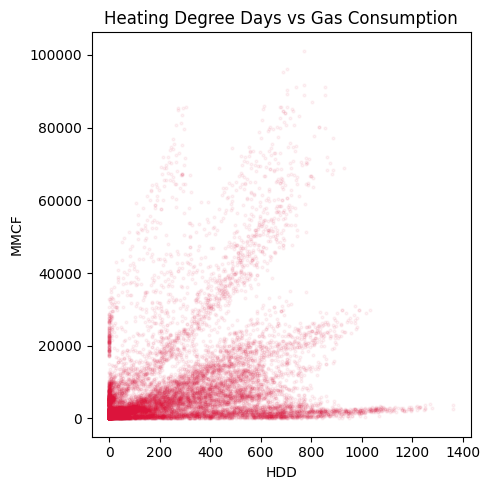

In [24]:
fig, axes = plt.subplots(figsize=(5, 5))

# HDD vs Gas
axes.scatter(merged_df["HDD"], merged_df["MMCF"], alpha=0.05, s=4, color="crimson")
axes.set_title("Heating Degree Days vs Gas Consumption", fontsize=12)
axes.set_xlabel("HDD")
axes.set_ylabel("MMCF")

plt.tight_layout()
plt.savefig("visualizations/HDDvsGas", dpi=150, bbox_inches="tight")
plt.show()

#### CDD vs Mkh Scatterplot

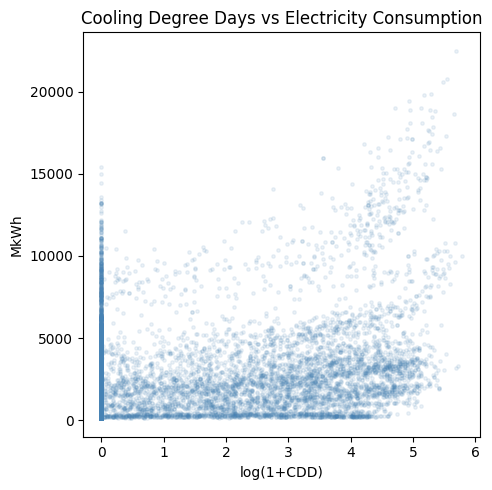

In [25]:
# CDD vs Electricity

fig, axes = plt.subplots(figsize=(5, 5))

axes.scatter(np.log1p(merged_df["CDD"]), merged_df["Mkh"], alpha=0.1, s=6, color="steelblue")
# axes.scatter(merged_df["CDD"], merged_df["Mkh"], alpha=0.1, s=6, color="steelblue")
axes.set_title("Cooling Degree Days vs Electricity Consumption", fontsize=12)
axes.set_xlabel("log(1+CDD)")
axes.set_ylabel("MkWh")

plt.tight_layout()
plt.savefig("visualizations/CDDvsElectricity", dpi=150, bbox_inches="tight")
plt.show()

#### Temp vs Consumption

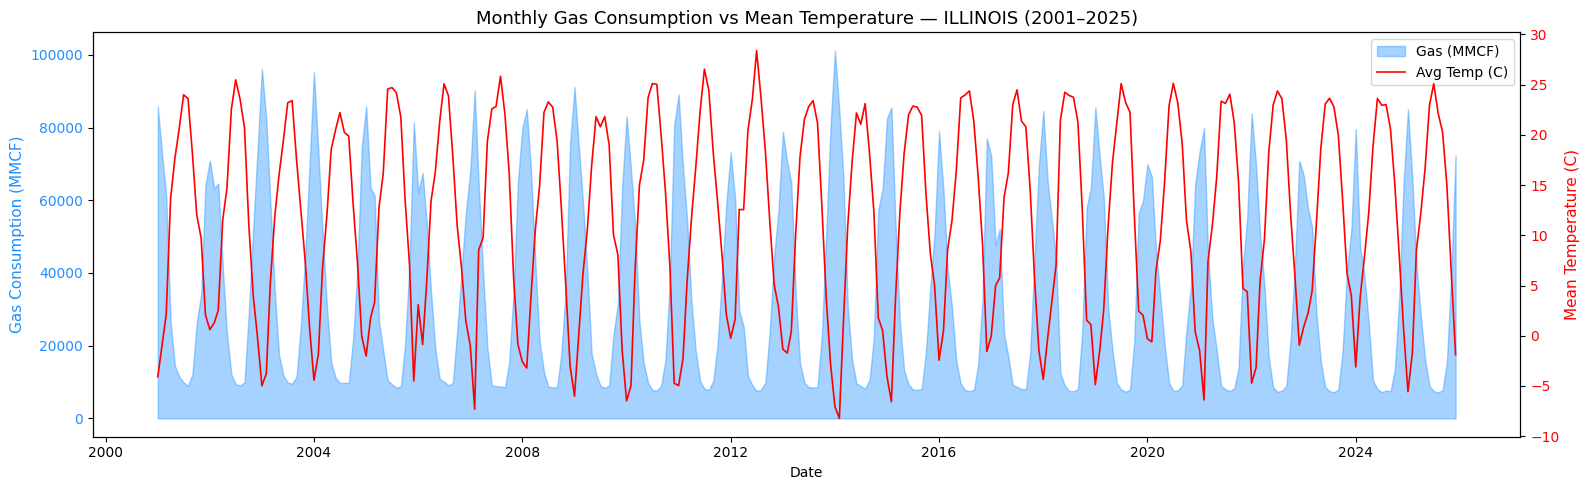

In [26]:
state = "ILLINOIS"
state_data = merged_df[merged_df["state"] == state].groupby(["year", "month"], as_index=False).agg(
    MMCF=("MMCF", "mean"),
    Mkh=("Mkh", "mean"),
    temp_mean_C=("temp_mean_C", "mean")
).sort_values(["year", "month"])

state_data["date"] = pd.to_datetime(state_data[["year", "month"]].assign(day=1))

fig, ax1 = plt.subplots(figsize=(16, 5))

# Gas consumption on left axis
ax1.fill_between(state_data["date"], state_data["MMCF"], alpha=0.4, color="dodgerblue", label="Gas (MMCF)")
ax1.set_ylabel("Gas Consumption (MMCF)", color="dodgerblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="dodgerblue")

# Temperature on right axis
ax2 = ax1.twinx()
ax2.plot(state_data["date"], state_data["temp_mean_C"], color="red", linewidth=1.2, label="Avg Temp (C)")
ax2.set_ylabel("Mean Temperature (C)", color="red", fontsize=11)
ax2.tick_params(axis="y", labelcolor="red")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title(f"Monthly Gas Consumption vs Mean Temperature — {state} (2001–2025)", fontsize=13)
ax1.set_xlabel("Date")
plt.tight_layout()
plt.savefig("visualizations/GasVsTemp", dpi=300, bbox_inches="tight")
plt.show()

#### Correlation Heatmap

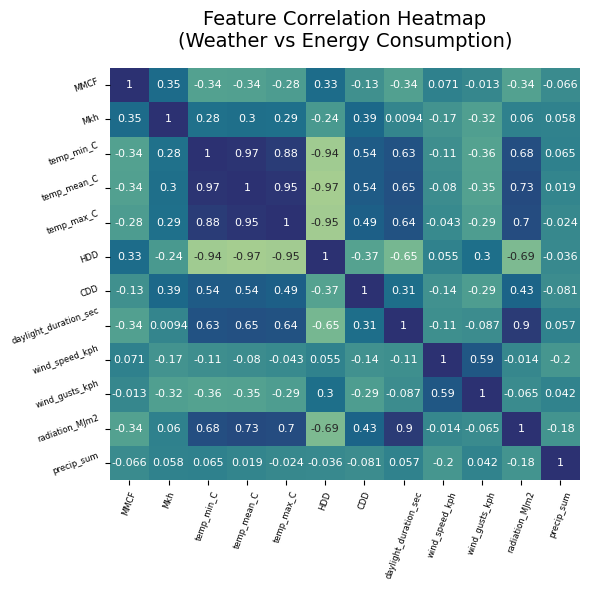

In [27]:
#Excludes lat, lon, and categorical variables
corr_cols = [
    "MMCF", "Mkh",
    "temp_min_C", "temp_mean_C", "temp_max_C",
    "HDD", "CDD",
    "daylight_duration_sec",
    "wind_speed_kph", "wind_gusts_kph",
    "radiation_MJm2", "precip_sum"
]

small_matrix = merged_df[corr_cols].corr()

# rename_dict = {
#     "temp_min_C": "Min Temp",
#     "temp_mean_C": "Mean Temp", 
#     "temp_max_C": "Max Temp",
#     "daylight_duration_sec": "Daylight",
#     "wind_speed_kph": "Wind Spd", 
#     "wind_gusts_kph": "Wind Gust",
#     "radiation_MJm2": "Radiation",
#     "precip_sum": "Precip."    
# }
# small_matrix = small_matrix.rename(index=rename_dict, columns=rename_dict)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    small_matrix,
    annot=True,
    cbar=False,
    cmap="crest",
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Feature Correlation Heatmap\n(Weather vs Energy Consumption)", fontsize=14, pad=15)
ax.tick_params(axis='x', labelsize=6, rotation = 70)
ax.tick_params(axis='y', labelsize=6, rotation = 20)

plt.tight_layout()
plt.savefig("visualizations/corr_heatmap", dpi=600, bbox_inches="tight")

Observations:
We see correlation between our target variables (MMCF, Mkh) is between(-0.34,0.36), which indicates a weak linear relationship. This implies linear models may have a poor performance and so we will choose a non-linear model.
We see a very strong postive correlation between radiation and daylight duration. Intuitively, this is expected as they are directly related.
We see a strong positive correlation between temperature measurements and daylight duration, aswell as with radiation since daylight and radiation are dependent as mentioned previously.
We also see very strong negative and postive relationships between our engineered heating/cooling degree days and our temperature measurements. This is expected as they are dependent on the mean temperature which is dependent on the min/max temperature.

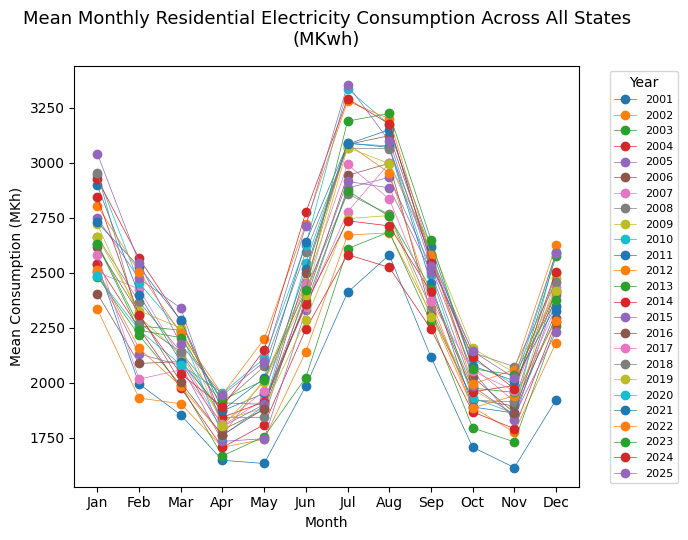

In [28]:
calendar_data = merged_df.groupby(["year", "month"])["Mkh"].mean().reset_index()
calendar_pivot = calendar_data.pivot(index="year", columns="month", values="Mkh")
calendar_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(7, 5.5))

# Plot each year as a line
for year in calendar_pivot.index:
    ax.plot(
        calendar_pivot.columns, 
        calendar_pivot.loc[year], 
        marker='o', 
        label=str(year),
        linewidth=0.5
    )

ax.set_title(
    "Mean Monthly Residential Electricity Consumption Across All States\n(MKwh)",
    fontsize=13,
    pad=15
)
ax.set_xlabel("Month")
ax.set_ylabel("Mean Consumption (MKh)")
ax.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig("visualizations/electricityConsump_line", dpi=150, bbox_inches="tight")
plt.show()

Calendar Heatmap

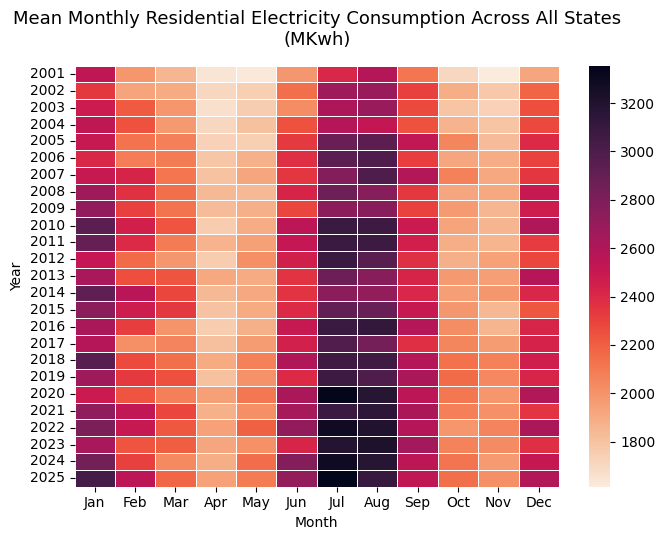

In [29]:
calendar_data = merged_df.groupby(["year", "month"])["Mkh"].mean().reset_index()
calendar_pivot = calendar_data.pivot(index="year", columns="month", values="Mkh")
calendar_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    calendar_pivot,
    cmap="rocket_r",
    linewidths=0.5,
    annot=False,
    fmt="2.0f",
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Mean Monthly Residential Electricity Consumption Across All States\n(MKwh)", fontsize=13, pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("visualizations/electricityConsump", dpi=600, bbox_inches="tight")
plt.show()

## Data Encoding

#### Cyclical Encoding for Months
Maps months to polar coordinates to preserve sequential relationship while imposing cyclic relationship

In [30]:
merged_df["month_x"] = np.sin(2*np.pi*merged_df["month"]/12)
merged_df["month_y"] = np.cos(2*np.pi*merged_df["month"]/12)
merged_df = merged_df.drop(columns=["month"])

#### One Hot Encoding for States

In [31]:
OHE = OneHotEncoder(sparse_output=False)
data_transformed = OHE.fit_transform(merged_df[["state"]])
encoded = pd.DataFrame(data_transformed, columns=OHE.get_feature_names_out(["state"]))
encoded_df = merged_df.join(encoded).drop(["state"], axis=1)
encoded_df

,year,MMCF,Mkh,temp_min_C,temp_mean_C,temp_max_C,daylight_duration_sec,wind_speed_kph,wind_gusts_kph,radiation_MJm2,...,state_SOUTHDAKOTA,state_TENNESSEE,state_TEXAS,state_UTAH,state_VERMONT,state_VIRGINIA,state_WASHINGTON,state_WESTVIRGINIA,state_WISCONSIN,state_WYOMING
0,2001,13490.0,3263.40254,-5.90,5.408387,17.90,36988.609581,14.106320,33.967741,320.94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2001,8987.0,2109.81427,-1.10,11.647143,24.95,39700.334536,15.031764,35.177142,333.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2001,5867.0,1919.16210,1.65,10.957419,21.85,43180.981097,15.414626,37.056773,465.81,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2001,4787.0,1886.08153,4.75,18.559667,28.55,46817.387600,14.746313,36.359999,618.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2001,1968.0,1945.31392,12.80,22.520000,31.85,49867.385871,12.726747,32.829677,741.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15328,2025,269.0,221.75183,7.17,17.459032,30.82,49920.731581,22.194400,51.131612,733.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15329,2025,300.0,184.29132,2.27,12.592000,23.52,44905.588567,20.089934,46.859999,564.38,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15330,2025,638.0,194.27971,-7.33,4.850000,21.32,39695.266065,26.055907,59.527741,417.94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15331,2025,1280.0,228.36392,-17.18,1.299333,13.92,35110.036733,26.081755,57.767998,279.44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Model

Helper Functions

In [32]:
def eval_model(model, X, y):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    print(f"R^2   : {r2:.4f}")
    rmse = np.sqrt(np.mean((y - pred)**2))
    print(f"RMSE : {rmse:.4f}")
    return model, r2, rmse

In [33]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def compute_CV_error(model, X_train, Y_train):
    splits = 5
    kf = KFold(n_splits = splits, shuffle = True)
    kf.get_n_splits()
    total_rmse = 0

    for train_index, test_index in kf.split(X_train, y=Y_train):
        if isinstance(X_train, np.ndarray):
            X_tr, X_val = X_train[train_index], X_train[test_index]
            y_tr, y_val = Y_train.iloc[train_index], Y_train.iloc[test_index]
        else:
            X_tr, X_val = X_train.iloc[train_index], X_train.iloc[test_index]  # keep as DataFrame
            y_tr, y_val = Y_train.iloc[train_index], Y_train.iloc[test_index]


        model.fit(X_tr, y_tr)
        Y_pred = model.predict(X_val)
        
        validation_error = rmse(y_val, Y_pred)
        print("Validation RMSE:", validation_error)
        total_rmse += validation_error

    return total_rmse/splits

#### Model - Baseline

In [34]:
baseline_model_gas = lm.LinearRegression() 
baseline_model_electricity = lm.LinearRegression() 

x_baseline = encoded_df[["year","month_x", "month_y"]]
y_gas = encoded_df["MMCF"]
y_electric = encoded_df["Mkh"]

X_train_gas, X_test_gas, y_train_gas, y_test_gas = train_test_split(
    x_baseline, y_gas, test_size=0.2, random_state=42
)
X_train_electric, X_test_electric, y_train_electric, y_test_electric = train_test_split(
    x_baseline, y_electric, test_size=0.2, random_state=42
)

model_baseline_gas = baseline_model_gas.fit(X_train_gas, y_train_gas)
model_baseline_electric = baseline_model_electricity.fit(X_train_electric, y_train_electric)

#### Model - Multiple Linear Regression

In [35]:
lin_model_gas = lm.LinearRegression()
lin_model_electricity = lm.LinearRegression()

X = encoded_df.drop(columns=["MMCF", "Mkh"])
y_gas = encoded_df["MMCF"]
y_electric = encoded_df["Mkh"]

X_train_gas_l, X_test_gas_l, y_train_gas_l, y_test_gas_l = train_test_split(
    X, y_gas, test_size=0.2, random_state=42
)
X_train_electric_l, X_test_electric_l, y_train_electric_l, y_test_electric_l = train_test_split(
    X, y_electric, test_size=0.2, random_state=42
)

#Fitting scalar after t/t split avoids data leakage
scaler_gas  = StandardScaler()
scaler_electricity  = StandardScaler()

#Fit on training only, transform on test
X_train_gas_scaled = scaler_gas.fit_transform(X_train_gas_l)
X_test_gas_scaled  = scaler_gas.transform(X_test_gas_l)

#Fit on training only, transform on test
X_train_electric_scaled = scaler_electricity.fit_transform(X_train_electric_l)
X_test_electric_scaled = scaler_electricity.transform(X_test_electric_l)

cv_error_gas_l = compute_CV_error(lin_model_gas, X_train_gas_scaled, y_train_gas_l)
cv_error_electric_l = compute_CV_error(lin_model_electricity, X_train_electric_scaled, y_train_electric_l)
print(f"GAS MEAN RMSE: {cv_error_gas_l}")
print(f"ELECTRICITY MEAN RMSE: {cv_error_electric_l}")

model_lr_gas = lin_model_gas.fit(X_train_gas_scaled, y_train_gas_l)
model_lr_electric = lin_model_electricity.fit(X_train_electric_scaled, y_train_electric_l)

Validation RMSE: 6786.087170493921
Validation RMSE: 6654.027155439483
Validation RMSE: 6805.28480607976
Validation RMSE: 6429.7674088955355
Validation RMSE: 6584.39543084045
Validation RMSE: 547.8564757319816
Validation RMSE: 560.7831158755572
Validation RMSE: 577.2633786274686
Validation RMSE: 549.6459657625671
Validation RMSE: 581.5011749702933
GAS MEAN RMSE: 6651.91239434983
ELECTRICITY MEAN RMSE: 563.4100221935736


#### Model - Random Forest

In [36]:
rf_gas = RandomForestRegressor(n_estimators=100, random_state=42)
rf_electric = RandomForestRegressor(n_estimators=100, random_state=42)

X = encoded_df.drop(columns=["MMCF", "Mkh"])
y_gas = encoded_df["MMCF"]
y_electric = encoded_df["Mkh"]

X_train_gas_r, X_test_gas_r, y_train_gas_r, y_test_gas_r = train_test_split(
    X, y_gas, test_size=0.2, random_state=42
)
X_train_electric_r, X_test_electric_r, y_train_electric_r, y_test_electric_r = train_test_split(
    X, y_electric, test_size=0.2, random_state=42
)

cv_error_gas_r = compute_CV_error(rf_gas, X_train_gas_r, y_train_gas_r)
cv_error_electric_r = compute_CV_error(rf_electric, X_train_electric_r, y_train_electric_r)
print(f"GAS MEAN RMSE: {cv_error_gas_r}")
print(f"ELECTRICITY MEAN RMSE: {cv_error_electric_r}")

# No scaling needed
model_rf_gas = rf_gas.fit(X_train_gas_r, y_train_gas_r)
model_rf_electric = rf_electric.fit(X_train_electric_r, y_train_electric_r)

Validation RMSE: 1483.338402149751
Validation RMSE: 1479.4786778143637
Validation RMSE: 1498.9284460455249
Validation RMSE: 1435.0076928764083
Validation RMSE: 1493.2450321947695
Validation RMSE: 258.32503166595205
Validation RMSE: 244.8867903322341
Validation RMSE: 230.91853685279318
Validation RMSE: 246.0186462322684
Validation RMSE: 233.1860007573607
GAS MEAN RMSE: 1477.9996502161634
ELECTRICITY MEAN RMSE: 242.66700116812166


## Evaluation

#### Baseline Evaluation

In [37]:
print("Baseline GAS EVAL (MMCF):")
lr_gas, _, _ = eval_model(model_baseline_gas, X_test_gas,  y_test_gas)
print("Baseline ELECTRICITY EVAL (Mkh)")
lr_electric, _, _ = eval_model(model_baseline_electric, X_test_electric, y_test_electric)

Baseline GAS EVAL (MMCF):
R^2   : 0.1776
RMSE : 11390.8854
Baseline ELECTRICITY EVAL (Mkh)
R^2   : 0.0011
RMSE : 2328.0717


#### Linear Regression Evaluation

In [38]:
print("GAS EVAL (MMCF):")
lr_gas, _, _ = eval_model(model_lr_gas, X_test_gas_scaled,  y_test_gas_l)
print("Electric EVAL (Mkh)")
lr_electric, _, _ = eval_model(model_lr_electric, X_test_electric_scaled, y_test_electric_l)

GAS EVAL (MMCF):
R^2   : 0.7323
RMSE : 6498.4882
Electric EVAL (Mkh)
R^2   : 0.9505
RMSE : 518.0918


#### Random Forest Evaluation

In [39]:
print("GAS EVAL (MMCF):")
rf_gas, _, _ = eval_model(model_rf_gas, X_test_gas_r, y_test_gas_r)
print("Electric EVAL (Mkh)")
rf_electricity, _, _ = eval_model(model_rf_electric, X_test_electric_r, y_test_electric_r)

GAS EVAL (MMCF):
R^2   : 0.9875
RMSE : 1404.3337
Electric EVAL (Mkh)
R^2   : 0.9908
RMSE : 223.8407
